## Target: Map
## Input: 5 time steps of 30 minutes (up to 2 hours before)

## Imports

In [46]:
from tensorflow.keras import layers, models                                             # type: ignore
import pandas as pd                                                                     # type: ignore
import matplotlib.pyplot as plt                                                         # type: ignore
import seaborn as sns                                                                   # type: ignore
import numpy as np                                                                      # type: ignore
from  sklearn import metrics                                                            # type: ignore
from sklearn.preprocessing import StandardScaler                                        # type: ignore
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss                  # type: ignore
from sklearn.metrics import average_precision_score                  # type: ignore
import tensorflow as tf                                                                 # type: ignore
from tensorflow.keras.initializers import he_normal # type: ignore
from tensorflow.keras.optimizers import Adam                                            # type: ignore
from sklearn.model_selection import train_test_split                                    # type: ignore
import matplotlib as mpl                                                                # type: ignore
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (9, 7)
from joblib import dump, load                                                           # type: ignore
from tensorflow.keras.layers import LSTM, Dense, Dropout                                # type: ignore

In [47]:
lead_time = 3

In [48]:
resolution = 11

## Read data

In [49]:
test_data_X = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/1h-before/csv-data/test-Dakar-map-features-many-timesteps-60min-lt{lead_time}-1h-before.csv", index_col=False)
test_data_y = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/1h-before/csv-data/test-Dakar-map-target-many-timesteps-60min-lt{lead_time}-1h-before.csv", index_col=False)

train_data_X = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/1h-before/csv-data/train-Dakar-map-features-many-timesteps-60min-lt{lead_time}-1h-before.csv", index_col=False)
train_data_y = pd.read_csv(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/map/1h-before/csv-data/train-Dakar-map-target-many-timesteps-60min-lt{lead_time}-1h-before.csv", index_col=False)

In [50]:
raw_test_X = test_data_X
raw_train_X, raw_validation_X, train_y, validation_y = train_test_split(train_data_X, train_data_y, test_size=0.3, random_state=12)

In [51]:
# Initial headers for time periods
t0 = "year,month,day,hour,minute,"
t60 = "year_60,month_60,day_60,hour_60,minute_60,"

# Initialize empty strings for loc, wp, ds, sz for t0 (current), t30, t60, t90, and t120
loc = wp = ds = sz = "" 
loc_60 = wp_60 = ds_60 = sz_60 = "" 

# Loop to generate the string for each time period (current, +30, +60, +90, +120 minutes)
for i in range(1, 6):
    # For the current time (t0)
    loc += f"lat{i},lon{i},"
    wp += f"wp{i},"
    ds += f"ds{i},"
    sz += f"size{i},"

    # For t60 (60 minutes later)
    loc_60 += f"lat{i}_60,lon{i}_60,"
    wp_60 += f"wp{i}_60,"
    ds_60 += f"ds{i}_60,"
    sz_60 += f"size{i}_60,"        

# Concatenate all headers for t0, t30, t60, t90, t120
headers = (t0 + loc + wp + sz + ds +            
           t60 + loc_60 + wp_60 + sz_60 + ds_60)

print(headers)


year,month,day,hour,minute,lat1,lon1,lat2,lon2,lat3,lon3,lat4,lon4,lat5,lon5,wp1,wp2,wp3,wp4,wp5,size1,size2,size3,size4,size5,ds1,ds2,ds3,ds4,ds5,year_60,month_60,day_60,hour_60,minute_60,lat1_60,lon1_60,lat2_60,lon2_60,lat3_60,lon3_60,lat4_60,lon4_60,lat5_60,lon5_60,wp1_60,wp2_60,wp3_60,wp4_60,wp5_60,size1_60,size2_60,size3_60,size4_60,size5_60,ds1_60,ds2_60,ds3_60,ds4_60,ds5_60,


## Preprocessing

In [52]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [53]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [54]:
# Concatenate headers for wp, sz, and ds across time periods with updated intervals
to_scale = f"{wp}{wp_60}{sz}{sz_60}{ds}{ds_60}".rstrip(',')

# Concatenate headers for time variables with updated intervals
t = f"{t0}{t60}".rstrip(',')

print(to_scale)
print(t)


wp1,wp2,wp3,wp4,wp5,wp1_60,wp2_60,wp3_60,wp4_60,wp5_60,size1,size2,size3,size4,size5,size1_60,size2_60,size3_60,size4_60,size5_60,ds1,ds2,ds3,ds4,ds5,ds1_60,ds2_60,ds3_60,ds4_60,ds5_60
year,month,day,hour,minute,year_60,month_60,day_60,hour_60,minute_60


In [55]:
def prepare(df):
    df = log_transform(df, to_scale.split(','))
    df = sqrt_transform(df, t.split(','))
    return df

### Transforming

In [56]:
transform = True
if transform:
    train_X = prepare(raw_train_X)
    validation_X = prepare(raw_validation_X)
    test_X = prepare(raw_test_X)

### Scaling

In [57]:
scaler = StandardScaler()
std_X_train = scaler.fit_transform(train_X)
std_X_val = scaler.transform(validation_X)
std_X_test = scaler.transform(test_X)

In [58]:
x_train = std_X_train.reshape(len(train_X), 2, 30)
y_train = tf.reshape(train_y, (len(train_y), resolution, resolution))

x_val = std_X_val.reshape(len(validation_X), 2, 30)
y_val = tf.reshape(validation_y, (len(validation_y), resolution, resolution))

x_test = std_X_test.reshape(len(test_X), 2, 30)
y_test = tf.reshape(test_data_y, (len(test_data_y), resolution, resolution))

In [59]:
y_test.shape

TensorShape([13083, 11, 11])

### Creating the model 

In [60]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=(2, 30)),
  LSTM(20, activation="relu"),
  tf.keras.layers.Dense(32, activation='relu', kernel_initializer=he_normal()),
  tf.keras.layers.Dense(resolution * resolution, activation='relu', kernel_initializer=he_normal()),
  tf.keras.layers.Reshape((resolution, resolution, 1)),
  tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_initializer=he_normal()),
  tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid', padding='same', kernel_initializer=he_normal()),
  tf.keras.layers.Reshape((resolution, resolution)),
])

In [61]:
cl_thresholds = 0.15

METRICS = [
      tf.keras.metrics.MeanSquaredError(name='bs'),
      tf.keras.metrics.TruePositives(name='tp'),
      tf.keras.metrics.TrueNegatives(name='tn'),                        
      tf.keras.metrics.Recall(name='recall', thresholds = cl_thresholds),
      tf.keras.metrics.Precision(name='precision', thresholds = cl_thresholds),
      tf.keras.metrics.AUC(name='auc'),
      tf.keras.metrics.AUC(name='prc', curve='PR'), 
      tf.keras.metrics.F1Score(name = 'f1_score',  threshold = cl_thresholds),
]

In [62]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_prc", 
    verbose=1,
    patience=10,
    mode='max',
    restore_best_weights=True)

In [63]:
"""l1_reg = tf.keras.regularizers.L1(0.1)
for layer in model.layers[:]:  
  layer.kernel_regularizer = l1_reg"""

'l1_reg = tf.keras.regularizers.L1(0.1)\nfor layer in model.layers[:]:  \n  layer.kernel_regularizer = l1_reg'

In [64]:
optimizer = Adam(clipvalue=1.0, learning_rate=1e-3)
model.compile(optimizer=optimizer, 
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
              metrics=[tf.keras.metrics.AUC(name='prc', curve='PR')])

In [65]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 20)             │         4,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 121)            │         3,993 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 11, 11, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 1)      │            33 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 11, 11)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,098 (35.54 KB)

 Trainable params: 9,098 (35.54 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
model_history = model.fit(x_train, 
                          y_train, 
                          epochs=500,                           
                          batch_size = 1024,         
                          callbacks = [early_stopping],
                          validation_data=(x_val, y_val)
                        )

Epoch 1/500


35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.6833 - prc: 0.1552 - val_loss: 0.5904 - val_prc: 0.1644
Epoch 2/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.5321 - prc: 0.1826 - val_loss: 0.3982 - val_prc: 0.3082
Epoch 3/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.3904 - prc: 0.3247 - val_loss: 0.3655 - val_prc: 0.3585
Epoch 4/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.3656 - prc: 0.3628 - val_loss: 0.3542 - val_prc: 0.3805
Epoch 5/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 0.3528 - prc: 0.3845 - val_loss: 0.3476 - val_prc: 0.3999
Epoch 6/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.3506 - prc: 0.4048 - val_loss: 0.3434 - val_prc: 0.4148
Epoch 7/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.3458 - prc: 0.4187 - val_loss: 0.3403 - val_prc: 0.4267
Epoch 8/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.3409 - prc: 0.4340 - val_loss: 0.3374 - val_prc: 0.4399
Epoch 9/500
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 0.3369 -

### Save model

In [67]:
dump(scaler, f'Dakar-map-lt{lead_time}-lstm-1h-before.bin', compress=True)
model.save(f'Dakar-map-lt{lead_time}-lstm-1h-before.keras')

In [68]:
n_test = test_data_y.shape[0]

In [69]:
pred_y_train = model.predict(x_train).flatten()
pred_y_test = model.predict(x_test).flatten()

1107/1107 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [70]:
idx = []
for i in range(y_test.shape[0]):
    idx.append(np.mean(y_test[i]))
idx_max = np.argmax(idx)
y_test[idx_max]

<tf.Tensor: shape=(11, 11), dtype=float64, numpy=
array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])>

In [71]:
raw_test_X.iloc[idx_max, :]

year          2020.00
month            9.00
day              5.00
hour            21.00
minute          15.00
lat1            14.47
lon1           -15.32
lat2            13.84
lon2           -15.09
lat3            14.42
lon3           -17.74
lat4            14.15
lon4           -15.90
lat5            13.39
lon5           -17.57
wp1          14403.00
wp2           9076.00
wp3          13414.00
wp4          11049.00
wp5          16404.00
size1         9625.00
size2         1650.00
size3         1175.00
size4         6900.00
size5         6250.00
ds1             22.47
ds2             40.01
ds3             42.11
ds4             51.43
ds5             55.15
year_60       2020.00
month_60         9.00
day_60           5.00
hour_60         22.00
minute_60       15.00
lat1_60         15.63
lon1_60        -16.94
lat2_60         15.00
lon2_60        -17.97
lat3_60         14.20
lon3_60        -15.90
lat4_60         15.72
lon4_60        -15.72
lat5_60         14.91
lon5_60        -15.23
wp1_60    

## ROC

In [72]:
def plot_roc(name, labels, predictions, **kwargs):
  fp, tp, _ = metrics.roc_curve(labels, predictions)
  plt.plot(100*fp, 100*tp, label=name, linewidth=2, **kwargs)
  plt.xlabel('False alarm [%]')
  plt.ylabel('Hit [%]')
  plt.xlim([0,100])
  plt.ylim([0,100])
  plt.grid(True)
  ax = plt.gca()
  ax.set_aspect('equal')

In [73]:
auc_train = roc_auc_score(y_train.numpy().flatten(), pred_y_train)
auc_test = roc_auc_score(y_test.numpy().flatten(), pred_y_test)

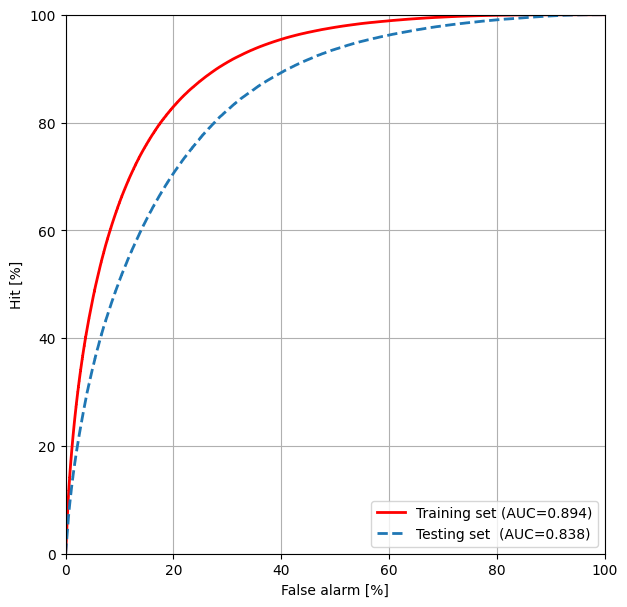

In [74]:
plot_roc(f"Training set (AUC={auc_train:.3f})", y_train.numpy().flatten(), pred_y_train.flatten(), color="red")
plot_roc(f"Testing set  (AUC={auc_test:.3f})", y_test.numpy().flatten(), pred_y_test.flatten(), color=colors[0], linestyle='--')
plt.legend(loc='lower right');

## Reliability diagram

In [75]:
def reliability_curve(y, y_pred, bin_size=0.1, count_pred_per_bin=100):
  y = np.array(y)
  y_pred = np.array(y_pred)
  bins = np.arange(0, 1+bin_size, bin_size)
  bin_centers = [(b1 + b2) / 2 for b1, b2 in zip(bins[:-1], bins[1:])]
  prop_positive = []
  bin_center_ax = []
  no_pred_per_bin = []
  for b1, b2, bc in zip(bins[:-1], bins[1:], bin_centers):
    in_bin = np.logical_and(y_pred >= b1, y_pred < b2)
    no_predictions_per_bin = np.sum(in_bin)
    no_positive_per_bin = np.sum(y[in_bin])    
    if no_predictions_per_bin > count_pred_per_bin:
      prop_pos = round(no_positive_per_bin/no_predictions_per_bin, 3)
      prop_positive.append(prop_pos)
      bin_center_ax.append(round(bc, 3))
      no_pred_per_bin.append(no_predictions_per_bin)
    else:
      continue
  return bin_center_ax, prop_positive, no_pred_per_bin

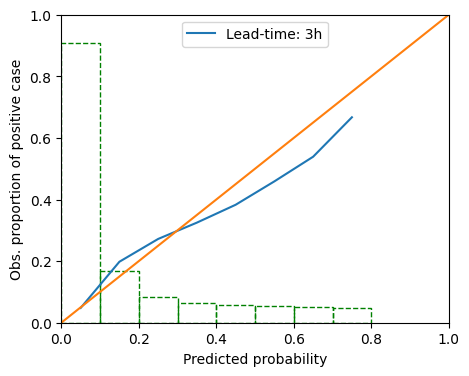

In [76]:
prob_pred, prob_true, no_pred_per_bin = reliability_curve(y_test.numpy().flatten(), pred_y_test.flatten())
plt.figure(figsize=(5,4))
plt.plot(prob_pred, prob_true, label=f"Lead-time: {lead_time}h")    
    
plt.xlabel("Predicted probability")
plt.ylabel("Obs. proportion of positive case")

no_pred_per_bin = [i/(1.1*np.max(no_pred_per_bin)) for i in no_pred_per_bin]
plt.plot(np.arange(0,1.2,0.2), np.arange(0,1.2,0.2))
plt.bar(prob_pred, no_pred_per_bin, width=0.1, linestyle="--", fill=False, edgecolor="green")

plt.xlim(0,1)
plt.ylim(0,1)
plt.legend(loc='upper center')
plt.show()

## Plotting

In [77]:
import cartopy.crs as ccrs                              # type: ignore
import cartopy.feature as cfeature                      # type: ignore
import warnings
warnings.filterwarnings("ignore")
from netCDF4 import Dataset                             # type: ignore

In [78]:
import sys
sys.path.insert(1, "/home/mendrika/mendrika-phd/codes/nflics")
import nflics  

In [79]:
geodata = Dataset("/home/mendrika/mendrika-phd/codes/nflics/geoloc_grids/nxny1640_580_nxnyds164580_blobdx0.04491576_area4_n23_20_32.nc")

xlimit = 1803
ylimit = 556

lons = geodata["lons_mid"][:ylimit, :xlimit]
lats = geodata["lats_mid"][:ylimit, :xlimit]

In [80]:
original_y_min, original_x_min = nflics.X0(13, -18)
original_y_max, original_x_max = nflics.X0(16, -15)

# To fix dimensions

y_min = original_y_min - 2
y_max = original_y_max + 2
x_min = original_x_min 
x_max = original_x_max + 1

In [81]:
def downsample_grid(grid, factor):
    # Ensure that the grid dimensions are divisible by the factor
    assert grid.shape[0] % factor == 0
    assert grid.shape[1] % factor == 0

    # Reshape the grid to factor blocks and then take the mean
    grid_downsampled = grid.reshape(grid.shape[0] // factor, factor,
                                    grid.shape[1] // factor, factor).mean(axis=(1, 3))
    
    return grid_downsampled

def create_lat_lon_grid(latitudes, longitudes, factor):
    lat_min = latitudes.min()
    lat_max = latitudes.max()
    lon_min = longitudes.min()
    lon_max = longitudes.max()
    
    num_rows = latitudes.shape[0] // factor
    num_cols = longitudes.shape[1] // factor
    
    new_lats = np.linspace(lat_min, lat_max, num_rows)
    new_lons = np.linspace(lon_min, lon_max, num_cols)
    
    new_latitudes, new_longitudes = np.meshgrid(new_lats, new_lons, indexing='ij')
    
    return new_latitudes, new_longitudes

In [82]:
if resolution == 11:
    downsampled_lats, downsampled_lons = create_lat_lon_grid(lats[y_min:y_max, x_min:x_max], lons[y_min:y_max, x_min:x_max], 10)
else:
    downsampled_lats, downsampled_lons = create_lat_lon_grid(lats[y_min:y_max, x_min:x_max], lons[y_min:y_max, x_min:x_max], 5)

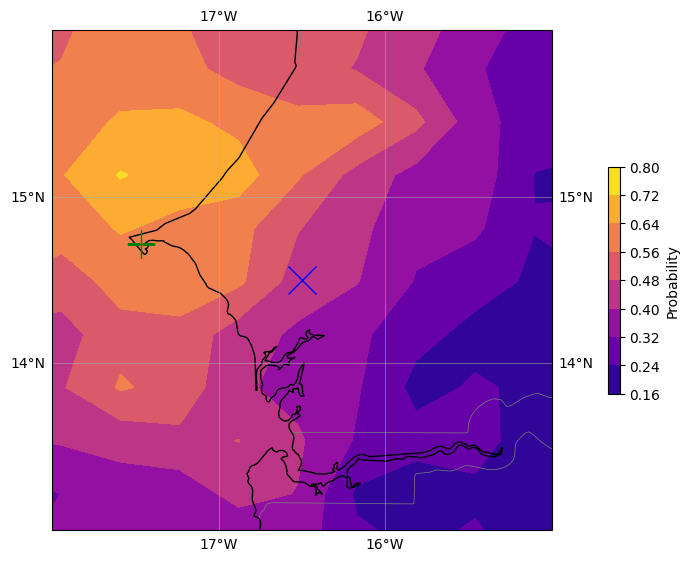

In [83]:
fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={'projection': ccrs.PlateCarree()})

extent = (-18, -15, 13, 16)
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, edgecolor='gray')
ax.tick_params(bottom=True, left=True, top=False, right=False)
    
gl = ax.gridlines(xlocs=np.array([-17, -16, -15]), 
                    ylocs=np.array([14, 15]), 
                    draw_labels=True, 
                    crs=ccrs.PlateCarree(),                
                    alpha=0.5
                )

Dakar_lon = -17.467686
Dakar_lat = 14.716677

center_lat = 14.5
center_lon = -16.5

contour_core = ax.contourf(downsampled_lons, downsampled_lats, pred_y_test.reshape(n_test, resolution, resolution)[idx_max], transform=ccrs.PlateCarree(), cmap="plasma")
plt.colorbar(contour_core, label="Probability", fraction=0.02, pad=0.1)

plt.plot(Dakar_lon, Dakar_lat, marker="+", color="green", markersize=20)
plt.plot(center_lon, center_lat, marker="x", color="blue", markersize=20)        
plt.tight_layout()
plt.show()

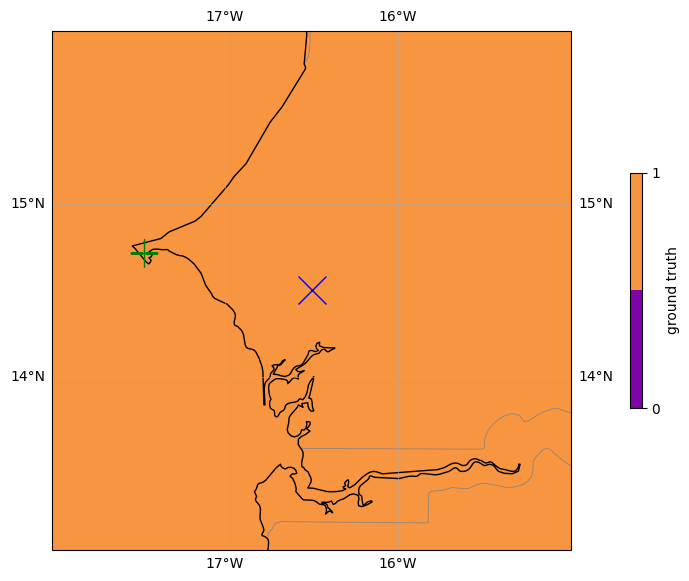

In [84]:
fig, ax = plt.subplots(figsize=(7, 10), subplot_kw={'projection': ccrs.PlateCarree()})

extent = (-18, -15, 13, 16)
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, edgecolor='gray')
ax.tick_params(bottom=True, left=True, top=False, right=False)
    
gl = ax.gridlines(xlocs=np.array([-17, -16, -15]), 
                    ylocs=np.array([14, 15]), 
                    draw_labels=True, 
                    crs=ccrs.PlateCarree(),                
                    alpha=0.5
                )

Dakar_lon = -17.467686
Dakar_lat = 14.716677

center_lat = 14.5
center_lon = -16.5

levels = [0, 0.5, 1]

contour_core = ax.contourf(downsampled_lons, downsampled_lats, y_test[idx_max], transform=ccrs.PlateCarree(), cmap="plasma", levels=levels)
cbar = plt.colorbar(contour_core, label="ground truth", fraction=0.02, pad=0.1)

cbar.set_ticks([0, 1])
cbar.set_ticklabels(['0', '1'])

plt.plot(Dakar_lon, Dakar_lat, marker="+", color="green", markersize=20)
plt.plot(center_lon, center_lat, marker="x", color="blue", markersize=20)        
plt.tight_layout()
plt.show()